In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def rotate_image(image, angle):
    """ Rotates an image by the given angle. """
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated_image = cv2.warpAffine(image, rotation_matrix, (w, h))
    return rotated_image

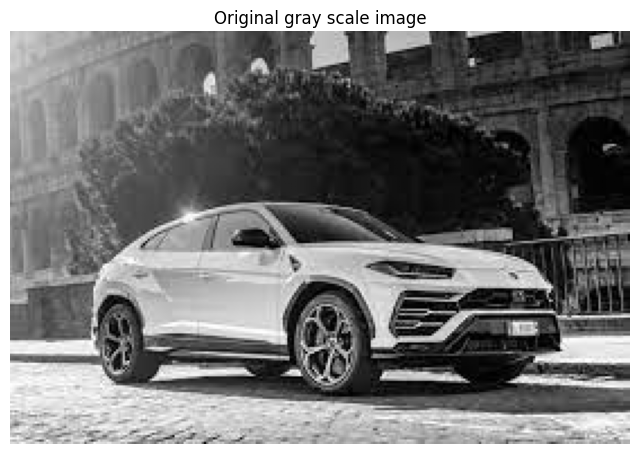

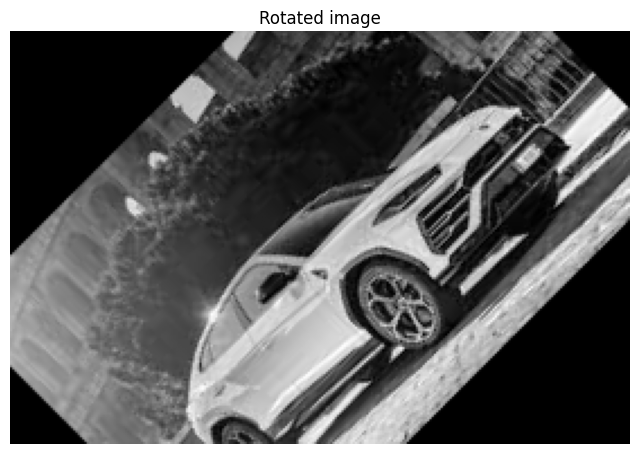

In [2]:
# Load the image in grayscale
image = cv2.imread("suv.jpeg", cv2.IMREAD_GRAYSCALE)

# Rotate the image by 45 degrees
rotated_image = rotate_image(image, 45)

# Display the image
plt.figure(figsize=(8, 6))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title("Original gray scale image")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(rotated_image, cmap="gray")
plt.axis("off")
plt.title("Rotated image")
plt.show()



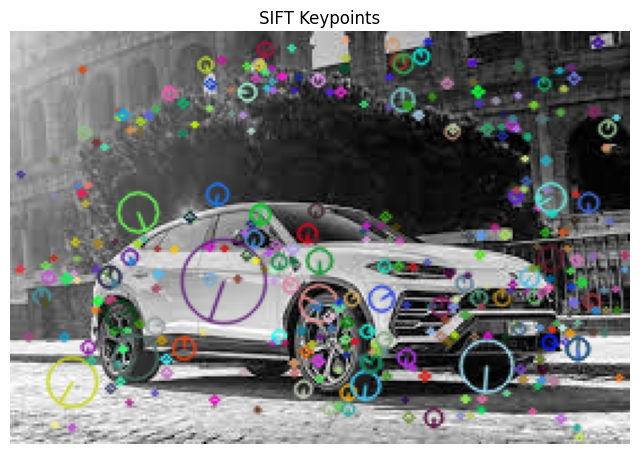

Number of keypoints detected: 407
Descriptor shape: (407, 128)


In [4]:
# Initialize SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and compute descriptors
keypoints, descriptors = sift.detectAndCompute(image, None)

# Draw keypoints on the image
image_with_keypoints = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Display the image with keypoints
plt.figure(figsize=(8, 6))
plt.imshow(image_with_keypoints, cmap="gray")
plt.axis("off")
plt.title("SIFT Keypoints")
plt.show()

# Print descriptor details
print(f"Number of keypoints detected: {len(keypoints)}")
print(f"Descriptor shape: {descriptors.shape}")  # (num_keypoints, 128)

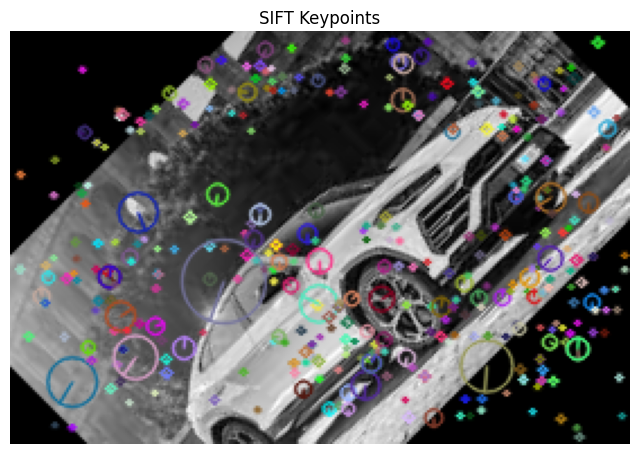

Number of keypoints detected: 385
Descriptor shape: (385, 128)


In [5]:
# Detect keypoints and compute descriptors for the rotated image
keypoints2, descriptors2 = sift.detectAndCompute(rotated_image, None)

# Draw keypoints on the image
rotated_image_with_keypoints = cv2.drawKeypoints(rotated_image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Display the image with keypoints
plt.figure(figsize=(8, 6))
plt.imshow(rotated_image_with_keypoints, cmap="gray")
plt.axis("off")
plt.title("SIFT Keypoints")
plt.show()

# Print descriptor details
print(f"Number of keypoints detected: {len(keypoints2)}")
print(f"Descriptor shape: {descriptors2.shape}")  # (num_keypoints, 128)


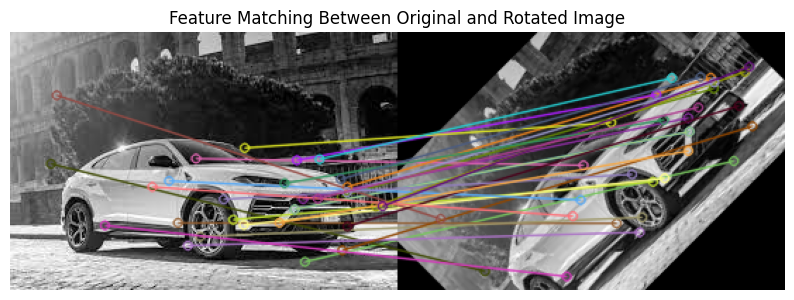

Number of keypoints in original image: 407
Number of keypoints in rotated image: 385
Number of matches found: 233
Similarity Score: 0.57


In [6]:
# Match descriptors using BFMatcher with L2 norm (for SIFT)
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(descriptors, descriptors2)

# Sort matches based on distance (lower is better)
matches = sorted(matches, key=lambda x: x.distance)

# Draw matches
image_matches = cv2.drawMatches(image, keypoints, rotated_image, keypoints2, matches[:30], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display the matched features
plt.figure(figsize=(10, 5))
plt.imshow(image_matches, cmap="gray")
plt.axis("off")
plt.title("Feature Matching Between Original and Rotated Image")
plt.show()

# Print results
print(f"Number of keypoints in original image: {len(keypoints)}")
print(f"Number of keypoints in rotated image: {len(keypoints2)}")
print(f"Number of matches found: {len(matches)}")

# Compute a similarity score (ratio of good matches to total keypoints)
similarity_score = len(matches) / max(len(keypoints), len(keypoints2))
print(f"Similarity Score: {similarity_score:.2f}")
